In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

# Carregar os dados

df = pd.read_csv("data_core_daily_v1.csv")
df["data"] = pd.to_datetime(df["data"])
df = df.sort_values(["CFGCENTROID","data"])


In [2]:
# Criar features mínimas necessárias
df["dow"] = df["data"].dt.dayofweek
df["week"] = df["data"].dt.isocalendar().week.astype(int)
df["month"] = df["data"].dt.month
df["is_saturday"] = (df["dow"] == 5).astype(int)

if "is_holiday" not in df.columns:
    df["is_holiday"] = 0

# Lags
for lag in [1,7,14,28]:
    df[f"lag_{lag}"] = (
        df.groupby("CFGCENTROID")["y_inspecoes"]
        .shift(lag)
    )

# Rolling
df["roll7_mean"] = (
    df.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

df["roll28_mean"] = (
    df.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(28)
    .mean()
    .reset_index(level=0, drop=True)
)

df_model = df.dropna().copy()

In [3]:
cutoff = df_model["data"].max() - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= cutoff]
test  = df_model[df_model["data"] > cutoff]

features_daily = [
    "CFGCENTROID",
    "dow",
    "week",
    "month",
    "is_saturday",
    "is_holiday",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll7_mean",
    "roll28_mean"
]

X_train = train[features_daily]
y_train = train["y_inspecoes"]

X_test = test[features_daily]
y_test = test["y_inspecoes"]

In [4]:
#Treinar modelo diário

model_daily = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

model_daily.fit(X_train, y_train)

pred_daily = model_daily.predict(X_test)
pred_daily = np.clip(pred_daily, 0, None)

In [5]:
#WAPE diário
wape_daily = np.sum(np.abs(y_test - pred_daily)) / np.sum(y_test)
print("WAPE diário:", round(wape_daily,4))

WAPE diário: 0.1114


In [6]:
# Agregar para semanal:
daily_test = test.copy()
daily_test["pred"] = pred_daily

daily_test["year"] = daily_test["data"].dt.isocalendar().year
daily_test["week"] = daily_test["data"].dt.isocalendar().week

weekly_from_daily = (
    daily_test
    .groupby(["CFGCENTROID","year","week"])
    .agg(
        real=("y_inspecoes","sum"),
        pred=("pred","sum")
    )
    .reset_index()
)

weekly_from_daily["abs_err"] = abs(weekly_from_daily["real"] - weekly_from_daily["pred"])

wape_weekly_from_daily = (
    weekly_from_daily["abs_err"].sum() /
    weekly_from_daily["real"].sum()
)

print("WAPE semanal (agregado do modelo diário):", round(wape_weekly_from_daily,4))

WAPE semanal (agregado do modelo diário): 0.054


In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import numpy as np
import pandas as pd

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "HGB": HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)
    
    wape_daily = np.sum(np.abs(y_test - pred)) / np.sum(y_test)
    
    # Agregação semanal
    tmp = test.copy()
    tmp["pred"] = pred
    tmp["year"] = tmp["data"].dt.isocalendar().year
    tmp["week"] = tmp["data"].dt.isocalendar().week
    
    weekly_tmp = (
        tmp.groupby(["CFGCENTROID","year","week"])
        .agg(real=("y_inspecoes","sum"),
             pred=("pred","sum"))
        .reset_index()
    )
    
    weekly_tmp["abs_err"] = abs(weekly_tmp["real"] - weekly_tmp["pred"])
    
    wape_weekly = (
        weekly_tmp["abs_err"].sum() /
        weekly_tmp["real"].sum()
    )
    
    results.append({
        "Model": name,
        "WAPE Diário": wape_daily,
        "WAPE Semanal": wape_weekly
    })

pd.DataFrame(results).sort_values("WAPE Diário")

,Model,WAPE Diário,WAPE Semanal
2,HGB,0.111361,0.054002
1,RandomForest,0.113554,0.047493
0,Ridge,0.130073,0.053902


In [8]:
from sklearn.ensemble import RandomForestRegressor

# Treinar RF
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = np.clip(rf.predict(X_test), 0, None)

# Treinar HGB
hgb = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

hgb.fit(X_train, y_train)
pred_hgb = np.clip(hgb.predict(X_test), 0, None)

# Ensemble (média simples)
pred_ensemble = (pred_hgb + pred_rf) / 2

# WAPE diário
wape_daily_ens = np.sum(np.abs(y_test - pred_ensemble)) / np.sum(y_test)
print("WAPE Diário Ensemble:", round(wape_daily_ens,4))

# Agregar semanal
tmp = test.copy()
tmp["pred"] = pred_ensemble
tmp["year"] = tmp["data"].dt.isocalendar().year
tmp["week"] = tmp["data"].dt.isocalendar().week

weekly_tmp = (
    tmp.groupby(["CFGCENTROID","year","week"])
    .agg(real=("y_inspecoes","sum"),
         pred=("pred","sum"))
    .reset_index()
)

weekly_tmp["abs_err"] = abs(weekly_tmp["real"] - weekly_tmp["pred"])
wape_weekly_ens = weekly_tmp["abs_err"].sum() / weekly_tmp["real"].sum()

print("WAPE Semanal Ensemble:", round(wape_weekly_ens,4))

WAPE Diário Ensemble: 0.11
WAPE Semanal Ensemble: 0.0488


In [9]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

center_volume = (
    df_model.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .reset_index()
)

median_vol = center_volume["y_inspecoes"].median()

large_centers = center_volume[
    center_volume["y_inspecoes"] > median_vol
]["CFGCENTROID"].values

train_large = train[train["CFGCENTROID"].isin(large_centers)]
test_large  = test[test["CFGCENTROID"].isin(large_centers)]

X_train_l = train_large[features_daily]
y_train_l = train_large["y_inspecoes"]

X_test_l = test_large[features_daily]
y_test_l = test_large["y_inspecoes"]

model_large = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

model_large.fit(X_train_l, y_train_l)
pred_large = np.clip(model_large.predict(X_test_l), 0, None)

wape_large = np.sum(np.abs(y_test_l - pred_large)) / np.sum(y_test_l)
print("WAPE centros grandes:", round(wape_large,4))

WAPE centros grandes: 0.1025


In [10]:
import pandas as pd
import numpy as np

# Escolher previsões automaticamente
# Preferência: ensemble -> hgb -> rf -> daily -> pred (genérico)
_pred_candidates = ["pred_ensemble", "pred_hgb", "pred_rf", "pred_daily", "pred"]
pred_vec = None
pred_name = None

for name in _pred_candidates:
    if name in globals():
        pred_vec = globals()[name]
        pred_name = name
        break

if pred_vec is None:
    raise ValueError("Não encontrei nenhum vetor de previsões (ex.: pred_ensemble, pred_hgb, pred_daily, pred).")

# Garantir que existe 'test'
if "test" not in globals():
    raise ValueError("Não encontrei o DataFrame 'test' no notebook semanal.")

df_out = test.copy()
df_out["y_pred"] = np.asarray(pred_vec)

# Agregar para semanal (centro-semana)
df_out["data"] = pd.to_datetime(df_out["data"])
iso = df_out["data"].dt.isocalendar()
df_out["year"] = iso.year.astype(int)
df_out["week"] = iso.week.astype(int)

weekly_center = (
    df_out
    .groupby(["CFGCENTROID", "year", "week"], as_index=False)
    .agg(
        real=("y_inspecoes", "sum"),
        pred=("y_pred", "sum")
    )
)

weekly_center["err"] = weekly_center["real"] - weekly_center["pred"]
weekly_center["abs_err"] = weekly_center["err"].abs()
weekly_center["sq_err"] = weekly_center["err"] ** 2

# Data (segunda-feira) da ISO week para filtrar 4 meses
weekly_center["week_start"] = pd.to_datetime(
    weekly_center["year"].astype(str) + "-W" + weekly_center["week"].astype(str) + "-1",
    format="%G-W%V-%u"
)

max_week_start = weekly_center["week_start"].max()
cutoff = max_week_start - pd.DateOffset(months=4)
weekly_center = weekly_center[weekly_center["week_start"] >= cutoff].copy()

# Métricas POR SEMANA (agregado sobre centros)
weekly_metrics = (
    weekly_center
    .groupby(["year", "week", "week_start"], as_index=False)
    .agg(
        real_total=("real", "sum"),
        pred_total=("pred", "sum"),
        MAE=("abs_err", "mean"),
        RMSE=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
        WAPE=("abs_err", "sum"),
        n_centers=("CFGCENTROID", "nunique")
    )
)

weekly_metrics["WAPE"] = weekly_metrics["WAPE"] / weekly_metrics["real_total"].replace(0, np.nan)
weekly_metrics["model_pred_used"] = pred_name

# Juntar métricas semanais ao detalhe centro-semana (fica “1 parquet só”, mas com as métricas da semana repetidas)
weekly_out = weekly_center.merge(
    weekly_metrics,
    on=["year", "week", "week_start"],
    how="left"
)

#Guardar
out_path = "output_semanal_4meses.parquet"
weekly_out.to_parquet(out_path, index=False)

print("OK", out_path)
print("Predições usadas:", pred_name)
print("Semanas:", weekly_out["week_start"].min().date(), "→", weekly_out["week_start"].max().date())
print("Linhas (centro-semana):", weekly_out.shape[0])

OK output_semanal_4meses.parquet
Predições usadas: pred_ensemble
Semanas: 2025-09-29 → 2025-12-29
Linhas (centro-semana): 714


In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

# Helpers
def pick_col(df, candidates, required=True, label=""):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"Não encontrei coluna {label}. Tentei: {candidates}. Colunas disponíveis: {list(df.columns)}"
        )
    return None

def iso_week_monday(year, week):
    return pd.to_datetime(
        year.astype(str) + "-W" + week.astype(str) + "-1",
        format="%G-W%V-%u"
    )

# Backtest semanal
# garante weekly_from_daily existe
if "weekly_from_daily" not in globals():
    # tenta reconstruir a partir do test + pred_daily/pred
    if "test" not in globals():
        raise ValueError("Não existe weekly_from_daily nem test no notebook.")
    if "pred_daily" in globals():
        _pred_vec = pred_daily
    elif "pred" in globals():
        _pred_vec = pred
    else:
        raise ValueError("Não encontrei pred_daily nem pred para reconstruir weekly_from_daily.")

    daily_test = test.copy()
    daily_test["pred_tmp"] = np.asarray(_pred_vec, dtype=float)

    daily_test["year"] = daily_test["data"].dt.isocalendar().year.astype(int)
    daily_test["week"] = daily_test["data"].dt.isocalendar().week.astype(int)

    weekly_from_daily = (
        daily_test.groupby(["CFGCENTROID", "year", "week"], as_index=False)
        .agg(real=("y_inspecoes", "sum"), prev=("pred_tmp", "sum"))
    )

wf = weekly_from_daily.copy()

# detetar colunas real e previsão
real_col = pick_col(wf, ["real", "y", "y_inspecoes", "actual", "value"], label="REAL (weekly_from_daily)")
pred_col = pick_col(wf, ["previsto", "prev", "pred", "y_pred", "yhat", "forecast"], label="PREVISTO (weekly_from_daily)")

# normalizar nomes
wf = wf.rename(columns={real_col: "real", pred_col: "previsto"})

# garantir year/week
if "year" not in wf.columns or "week" not in wf.columns:
    # tenta inferir de DATE se existir
    if "DATE" in wf.columns:
        _d = pd.to_datetime(wf["DATE"])
        wf["year"] = _d.dt.isocalendar().year.astype(int)
        wf["week"] = _d.dt.isocalendar().week.astype(int)
    else:
        raise KeyError("weekly_from_daily precisa de colunas year/week ou DATE.")

wf["DATE"] = iso_week_monday(wf["year"].astype(int), wf["week"].astype(int))

# janela ~2 meses
wf_max = wf["DATE"].max()
wf_cut = wf_max - pd.DateOffset(days=61)
wf_win = wf[wf["DATE"] >= wf_cut].copy()

wf_win["err"] = wf_win["real"] - wf_win["previsto"]
wf_win["abs_err"] = wf_win["err"].abs()
wf_win["sq_err"] = wf_win["err"] ** 2

metrics_semanal = (
    wf_win.groupby("CFGCENTROID", as_index=False)
    .agg(
        real=("real", "sum"),
        previsto=("previsto", "sum"),
        mae=("abs_err", "mean"),
        rmse=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
        wape=("abs_err", "sum"),
    )
)
metrics_semanal["wape"] = metrics_semanal["wape"] / metrics_semanal["real"].replace(0, np.nan)

metrics_semanal.to_parquet("metrics_semanal.parquet", index=False)
print("OK metrics_semanal.parquet")

# DADOS semanais: history 2 meses + forecast 2 meses
# usa df se existir
hist_daily = df.copy() if "df" in globals() else None
if hist_daily is None:
    raise ValueError("Não encontrei df no notebook semanal para construir history.")

hist_daily["data"] = pd.to_datetime(hist_daily["data"])
hist_max = hist_daily["data"].max()
hist_cut = hist_max - pd.DateOffset(days=61)

hist_win = hist_daily[hist_daily["data"] >= hist_cut].copy()
hist_win["year"] = hist_win["data"].dt.isocalendar().year.astype(int)
hist_win["week"] = hist_win["data"].dt.isocalendar().week.astype(int)

hist_week = (
    hist_win.groupby(["CFGCENTROID", "year", "week"], as_index=False)
    .agg(value=("y_inspecoes", "sum"))
)
hist_week["DATE"] = iso_week_monday(hist_week["year"], hist_week["week"])
hist_week["kind"] = "history"
history_long = hist_week[["CFGCENTROID", "DATE", "value", "kind"]].copy()

#  FORECAST
if "df_model" not in globals():
    df_model = df.dropna().copy()

if "features_daily" not in globals():
    raise ValueError("Não encontrei features_daily no notebook semanal.")

model_final = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.05, max_iter=400, random_state=42
)
model_final.fit(df_model[features_daily], df_model["y_inspecoes"])

last_date = pd.to_datetime(df_model["data"]).max()
future_days = pd.date_range(
    last_date + pd.Timedelta(days=1),
    last_date + pd.Timedelta(days=61),
    freq="D"
)
future_days = future_days[future_days.dayofweek <= 5]  # sem domingos

hol_set = set(holidays) if "holidays" in globals() else set()

# séries por centro para lags
hist_series = {}
tmp_hist = df_model[["CFGCENTROID", "data", "y_inspecoes"]].copy()
tmp_hist["data"] = pd.to_datetime(tmp_hist["data"])
for c, g in tmp_hist.groupby("CFGCENTROID"):
    g = g.sort_values("data")
    hist_series[c] = list(g["y_inspecoes"].astype(float).values)

def get_lag(seq, k):
    return seq[-k] if len(seq) >= k else np.nan

def get_roll(seq, k):
    return float(np.mean(seq[-k:])) if len(seq) >= k else np.nan

rows = []
centers = df_model["CFGCENTROID"].unique()

for d in future_days:
    dow = d.dayofweek
    is_saturday = 1 if dow == 5 else 0
    week = int(d.isocalendar().week)
    month = int(d.month)
    is_holiday = 1 if d.normalize() in hol_set else 0

    for c in centers:
        seq = hist_series[c]

        feat = {
            "CFGCENTROID": c,
            "dow": dow,
            "week": week,
            "month": month,
            "is_saturday": is_saturday,
            "is_holiday": is_holiday,
        }

        # adicionar lags/rolls que existirem em features_daily
        if "lag_1" in features_daily: feat["lag_1"] = get_lag(seq, 1)
        if "lag_7" in features_daily: feat["lag_7"] = get_lag(seq, 7)
        if "lag_14" in features_daily: feat["lag_14"] = get_lag(seq, 14)
        if "lag_28" in features_daily: feat["lag_28"] = get_lag(seq, 28)
        if "roll7_mean" in features_daily: feat["roll7_mean"] = get_roll(seq[:-1], 7) if len(seq) >= 2 else np.nan
        if "roll28_mean" in features_daily: feat["roll28_mean"] = get_roll(seq[:-1], 28) if len(seq) >= 2 else np.nan

        X = pd.DataFrame([feat])

        # garantir mesmas colunas e ordem
        for col in features_daily:
            if col not in X.columns:
                X[col] = np.nan
        X = X[features_daily]

        yhat = float(model_final.predict(X)[0])
        yhat = max(0.0, yhat)
        if is_holiday == 1:
            yhat = 0.0

        rows.append((c, d, yhat))
        hist_series[c].append(yhat)

forecast_daily = pd.DataFrame(rows, columns=["CFGCENTROID", "data", "yhat"])
forecast_daily["year"] = forecast_daily["data"].dt.isocalendar().year.astype(int)
forecast_daily["week"] = forecast_daily["data"].dt.isocalendar().week.astype(int)

forecast_week = (
    forecast_daily.groupby(["CFGCENTROID", "year", "week"], as_index=False)
    .agg(value=("yhat", "sum"))
)
forecast_week["DATE"] = iso_week_monday(forecast_week["year"], forecast_week["week"])

# ===================== FIX PRINCIPAL (SEM SOBREPOSIÇÃO) =====================
# Remove qualquer semana prevista que tenha a mesma DATE (segunda-feira ISO)
# que a última semana do histórico.
last_hist_week_date = history_long["DATE"].max()
forecast_week = forecast_week[forecast_week["DATE"] > last_hist_week_date].copy()
# ===========================================================================

forecast_week["kind"] = "forecast"
forecast_long = forecast_week[["CFGCENTROID", "DATE", "value", "kind"]].copy()

dados_semanal = (
    pd.concat([history_long, forecast_long], ignore_index=True)
    .sort_values(["CFGCENTROID", "DATE", "kind"])
)

# Guardrails opcionais (recomendado)
dups_date = dados_semanal.duplicated(subset=["CFGCENTROID", "DATE"]).sum()
assert dups_date == 0, f"Há {dups_date} semanas repetidas (CFGCENTROID+DATE) entre history e forecast"

dados_semanal.to_parquet("dados_semanal.parquet", index=False)
print("OK dados_semanal.parquet")

OK metrics_semanal.parquet
OK dados_semanal.parquet


In [12]:
metrics_semanal.describe()

,CFGCENTROID,real,previsto,mae,rmse,wape
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,92.647059,5722.764706,5633.137450,37.745787,47.882739,0.060897
std,77.687277,1635.209498,1595.783495,10.776037,13.742705,0.012943
min,4.000000,2870.000000,2798.278330,20.595665,23.328571,0.034342
25%,27.500000,4461.000000,4385.427287,29.728931,37.660743,0.051524
50%,60.000000,5575.000000,5618.570999,35.240039,45.620724,0.059337
75%,182.000000,6919.000000,6823.928173,43.563724,54.580275,0.070393
max,241.000000,10708.000000,10406.707494,68.339948,85.785100,0.091822


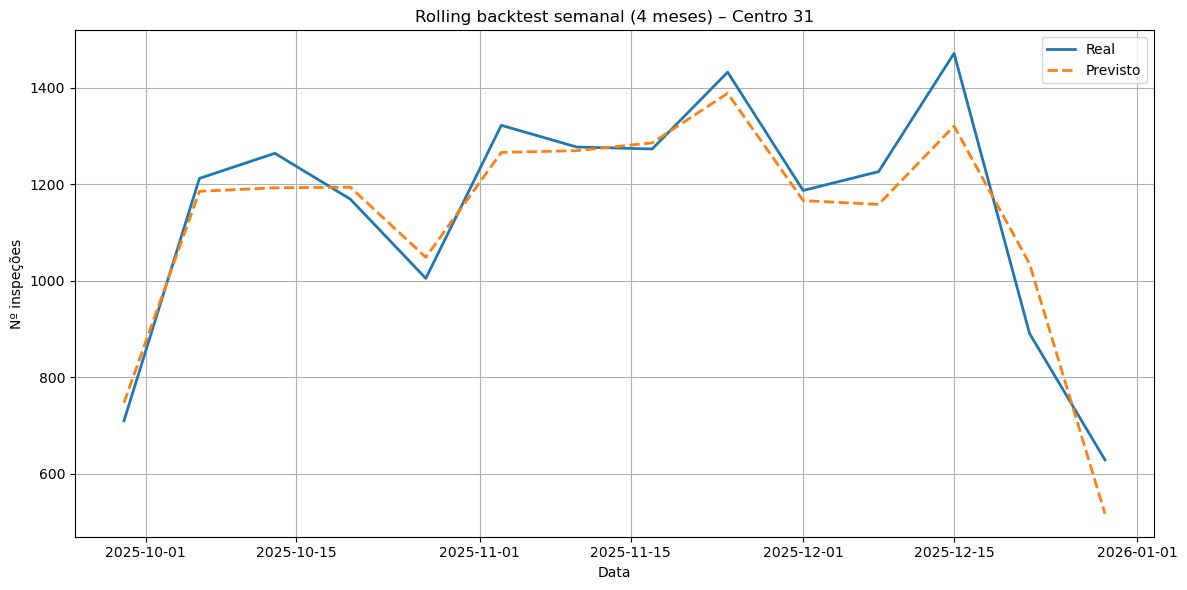

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Garantir que weekly_from_daily existe
if "weekly_from_daily" not in globals():
    raise ValueError("weekly_from_daily não existe no notebook.")

wf = weekly_from_daily.copy()

# Normalizar nomes das colunas
real_col = None
pred_col = None

for c in ["real", "y", "y_inspecoes"]:
    if c in wf.columns:
        real_col = c
        break

for c in ["previsto", "prev", "pred", "y_pred", "yhat"]:
    if c in wf.columns:
        pred_col = c
        break

if real_col is None or pred_col is None:
    raise ValueError("Não encontrei colunas real ou previsto.")

wf = wf.rename(columns={real_col: "real", pred_col: "previsto"})

#Criar DATE (segunda-feira da ISO week)
wf["DATE"] = pd.to_datetime(
    wf["year"].astype(str) + "-W" + wf["week"].astype(str) + "-1",
    format="%G-W%V-%u"
)

# Filtrar Centro 31
wf_31 = wf[wf["CFGCENTROID"] == 31].copy()
wf_31 = wf_31.sort_values("DATE")

#Filtrar últimos 4 meses (~122 dias ≈ 17 semanas)
max_date = wf_31["DATE"].max()
cutoff = max_date - pd.DateOffset(months=4)
wf_31 = wf_31[wf_31["DATE"] >= cutoff]

# Plot
plt.figure(figsize=(12,6))

plt.plot(wf_31["DATE"], wf_31["real"], linewidth=2, label="Real")
plt.plot(wf_31["DATE"], wf_31["previsto"], linestyle="--", linewidth=2, label="Previsto")

plt.title("Rolling backtest semanal (4 meses) – Centro 31")
plt.xlabel("Data")
plt.ylabel("Nº inspeções")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

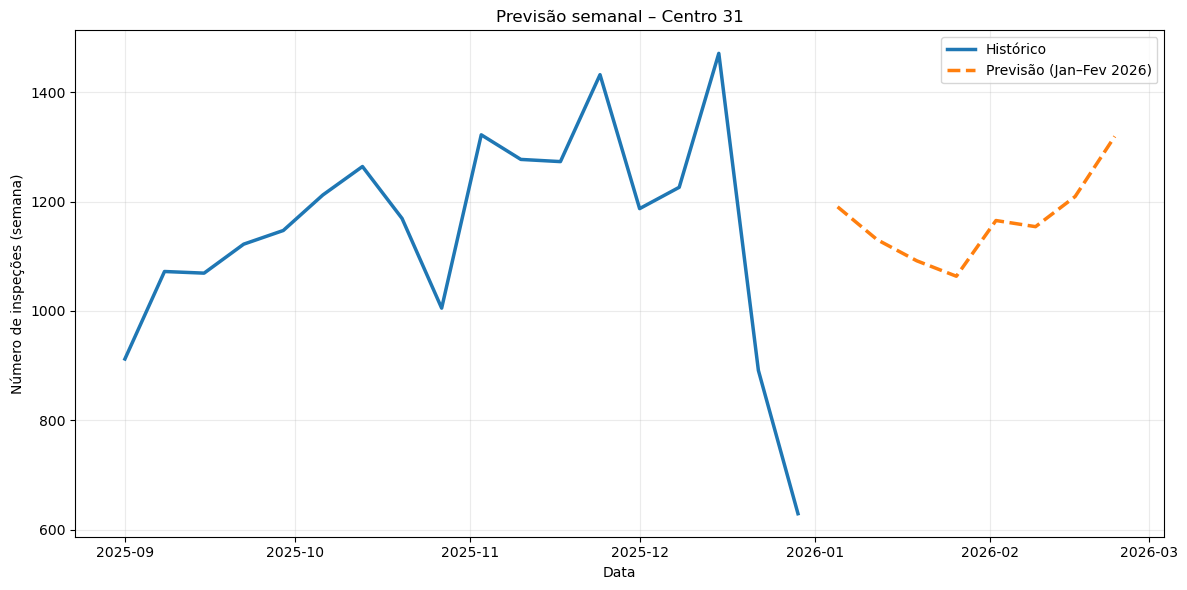

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# ============================================================
# 0) Fonte "real" usada no modelo
# ============================================================
# Preferência: df_model (já com features). Se não existir, usa df.
if "df_model" in globals():
    df_src = df_model.copy()
elif "df" in globals():
    df_src = df.copy()
else:
    raise ValueError("Não encontrei df_model nem df no notebook.")

df_src["data"] = pd.to_datetime(df_src["data"])

CENTER = 31

# Coluna target (real)
target_col = "y_inspecoes" if "y_inspecoes" in df_src.columns else "y"
if target_col not in df_src.columns:
    raise ValueError("Não encontrei coluna target ('y_inspecoes' ou 'y').")

# Lista de features (usar a do teu notebook se existir)
feat_candidates = ["features_daily", "features", "FEATURES"]
features = None
for name in feat_candidates:
    if name in globals() and isinstance(globals()[name], (list, tuple)):
        features = list(globals()[name])
        break

# fallback: usa colunas típicas temporais + centro (apenas se existirem)
if features is None:
    possible = [
        "CFGCENTROID", "dow", "week", "month", "year", "is_saturday", "is_holiday",
        "lag_1", "lag_7", "lag_14", "lag_28", "roll7_mean", "roll28_mean"
    ]
    features = [c for c in possible if c in df_src.columns]

# Garantir que features existem mesmo
features = [c for c in features if c in df_src.columns]
if len(features) == 0:
    raise ValueError("Não encontrei nenhuma feature utilizável em df_model/df.")

# Garantir que CFGCENTROID existe
if "CFGCENTROID" not in df_src.columns:
    raise ValueError("df_model/df não tem CFGCENTROID.")

# ============================================================
# 1) Criar/garantir colunas temporais mínimas (se forem necessárias)
# ============================================================
def ensure_time_cols(df, features):
    df = df.copy()
    if "dow" in features and "dow" not in df.columns:
        df["dow"] = df["data"].dt.dayofweek
    if "week" in features and "week" not in df.columns:
        df["week"] = df["data"].dt.isocalendar().week.astype(int)
    if "month" in features and "month" not in df.columns:
        df["month"] = df["data"].dt.month.astype(int)
    if "year" in features and "year" not in df.columns:
        df["year"] = df["data"].dt.year.astype(int)
    if "is_saturday" in features and "is_saturday" not in df.columns:
        df["is_saturday"] = (df["data"].dt.dayofweek == 5).astype(int)
    if "is_holiday" in features and "is_holiday" not in df.columns:
        # default: 0 (vai ser preenchido abaixo se holidays existir)
        df["is_holiday"] = 0
    return df

df_src = ensure_time_cols(df_src, features)

# Feriados (se existir lista "holidays" no teu notebook)
hol_set = set(pd.to_datetime(list(holidays)).normalize()) if "holidays" in globals() else set()

# Se feature is_holiday existir, preencher no histórico (importante!)
if "is_holiday" in features:
    df_src["is_holiday"] = df_src["data"].dt.normalize().isin(hol_set).astype(int)

# ============================================================
# 2) Treinar modelo diário no histórico ATÉ 2025-12-31
# ============================================================
train_end = pd.Timestamp("2025-12-31")
df_train = df_src[df_src["data"] <= train_end].copy()

# remover linhas com NA nas features/target
df_train = df_train.dropna(subset=features + [target_col]).copy()

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)
model.fit(df_train[features], df_train[target_col])

# ============================================================
# 3) Forecast diário recursivo para 2026-01-01 a 2026-02-28
# ============================================================
future_days = pd.date_range("2026-01-01", "2026-02-28", freq="D")
# excluir domingos (se este for o teu standard operacional)
future_days = future_days[future_days.dayofweek <= 5]

centers = df_train["CFGCENTROID"].unique()

# preparar séries históricas por centro para lags/roll (se forem usadas)
hist_series = {}
for c, g in df_train.sort_values("data").groupby("CFGCENTROID"):
    hist_series[c] = list(g[target_col].astype(float).values)

def get_lag(seq, k):
    return seq[-k] if len(seq) >= k else np.nan

def get_roll(seq, k):
    return float(np.mean(seq[-k:])) if len(seq) >= k else np.nan

rows = []

for d in future_days:
    # temporais base
    base_feat = {"data": d, "CFGCENTROID": None}

    if "dow" in features: base_feat["dow"] = d.dayofweek
    if "week" in features: base_feat["week"] = int(d.isocalendar().week)
    if "month" in features: base_feat["month"] = int(d.month)
    if "year" in features: base_feat["year"] = int(d.year)
    if "is_saturday" in features: base_feat["is_saturday"] = 1 if d.dayofweek == 5 else 0
    if "is_holiday" in features: base_feat["is_holiday"] = 1 if d.normalize() in hol_set else 0

    for c in centers:
        seq = hist_series[c]
        feat = dict(base_feat)
        feat["CFGCENTROID"] = c

        # lags/rolls só se o modelo usar essas colunas
        if "lag_1" in features: feat["lag_1"] = get_lag(seq, 1)
        if "lag_7" in features: feat["lag_7"] = get_lag(seq, 7)
        if "lag_14" in features: feat["lag_14"] = get_lag(seq, 14)
        if "lag_28" in features: feat["lag_28"] = get_lag(seq, 28)

        # rolling: usa SEMPRE apenas o histórico já disponível (inclui previsões passadas)
        if "roll7_mean" in features: feat["roll7_mean"] = get_roll(seq, 7)
        if "roll28_mean" in features: feat["roll28_mean"] = get_roll(seq, 28)

        X = pd.DataFrame([feat])

        # garantir colunas e ordem
        for col in features:
            if col not in X.columns:
                X[col] = np.nan
        X = X[features]

        yhat = float(model.predict(X)[0])
        yhat = max(0.0, yhat)

        # regra opcional: se tens is_holiday, zero nesses dias
        if "is_holiday" in features and feat.get("is_holiday", 0) == 1:
            yhat = 0.0

        rows.append((c, d, yhat))
        hist_series[c].append(yhat)

df_fcst_daily = pd.DataFrame(rows, columns=["CFGCENTROID", "data", "yhat"])

# ============================================================
# 4) Agregar a semanal (DATE = segunda-feira ISO)
#    FIX: garantir que forecast semanal começa na semana seguinte
# ============================================================
def week_monday(dt_series):
    iso = dt_series.dt.isocalendar()
    year = iso.year.astype(str)
    week = iso.week.astype(str)
    return pd.to_datetime(year + "-W" + week + "-1", format="%G-W%V-%u")

# Forecast semanal
df_fcst_daily["DATE"] = week_monday(df_fcst_daily["data"])
fcst_week = (
    df_fcst_daily.groupby(["CFGCENTROID", "DATE"], as_index=False)
    .agg(previsto=("yhat", "sum"))
)

# History semanal (do mesmo df_train usado no modelo)
df_hist_daily = df_train[["CFGCENTROID", "data", target_col]].copy()
df_hist_daily["DATE"] = week_monday(df_hist_daily["data"])
hist_week = (
    df_hist_daily.groupby(["CFGCENTROID", "DATE"], as_index=False)
    .agg(real=(target_col, "sum"))
)

# ===================== FIX PRINCIPAL (SEM SOBREPOSIÇÃO) =====================
# Remove semanas do forecast cuja DATE (segunda ISO) seja <= última semana do histórico.
last_hist_week_date = hist_week["DATE"].max()
fcst_week = fcst_week[fcst_week["DATE"] > last_hist_week_date].copy()
# ===========================================================================

# ============================================================
# 5) Filtrar Centro 31 e criar dataset para plot:
#     - history: últimos 4 meses antes de 2026
#     - forecast: Jan–Fev 2026 (já sem a semana de overlap)
# ============================================================
hist_31 = hist_week[hist_week["CFGCENTROID"] == CENTER].sort_values("DATE")
fcst_31 = fcst_week[fcst_week["CFGCENTROID"] == CENTER].sort_values("DATE")

# últimos 4 meses do histórico (até 2025-12-31)
hist_cut = pd.Timestamp("2025-12-31") - pd.DateOffset(months=4)
hist_31 = hist_31[hist_31["DATE"] >= hist_cut].copy()

# Guardrail: garantir que não existe overlap no plot
overlap = set(hist_31["DATE"]).intersection(set(fcst_31["DATE"]))
assert len(overlap) == 0, f"Overlapping DATEs entre histórico e forecast: {sorted(list(overlap))[:10]}"

# ============================================================
# 6) Plot (estilo PowerPoint)
# ============================================================
plt.figure(figsize=(12, 6))

plt.plot(hist_31["DATE"], hist_31["real"], linewidth=2.5, label="Histórico")
plt.plot(fcst_31["DATE"], fcst_31["previsto"], linewidth=2.5, linestyle="--", label="Previsão (Jan–Fev 2026)")

plt.title("Previsão semanal – Centro 31")
plt.xlabel("Data")
plt.ylabel("Número de inspeções (semana)")
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

# opcional: exportar imagem para PowerPoint
# plt.savefig("previsao_semanal_centro31_jan_fev_2026.png", dpi=300, bbox_inches="tight")